In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
master_df = pd.read_csv(r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\data\master_data.csv', index_col=0)

In [4]:
master_df = master_df.astype({'year':str})
master_df['votes'] = pd.to_numeric(master_df['votes'])
master_df.head()

,year,position,province,color,candidate,votes
0,2004,President,Abra,#B0E0E6,Gloria_Arroyo,32644
1,2004,President,Agusan del Norte,#B0E0E6,Gloria_Arroyo,138402
2,2004,President,Agusan del Sur,#B0E0E6,Gloria_Arroyo,100998
3,2004,President,Aklan,#B0E0E6,Gloria_Arroyo,87197
4,2004,President,Albay,#B0E0E6,Gloria_Arroyo,172777


In [5]:
df = master_df.loc[(master_df['year']=='2004') &( master_df['position']=='President')]

In [6]:
electoral_votes = pd.read_csv(r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\data\2004_Reps.csv', index_col=0)
electoral_votes = electoral_votes[['province', 'electors']]

In [7]:
electoral_votes.head()

,province,electors
0,Abra,1
1,Agusan del Norte,2
2,Agusan del Sur,1
3,Aklan,1
4,Albay,3


In [8]:
df = pd.merge(df, electoral_votes, on='province', how='left')

In [9]:
idx = df.groupby('province')['votes'].idxmax()
df = df.loc[idx]

In [10]:
df

,year,position,province,color,candidate,votes,electors
101,2004,President,Abra,#0038A8,Fernando_Poe_Jr,50866,1
1,2004,President,Agusan del Norte,#B0E0E6,Gloria_Arroyo,138402,2
2,2004,President,Agusan del Sur,#B0E0E6,Gloria_Arroyo,100998,1
3,2004,President,Aklan,#B0E0E6,Gloria_Arroyo,87197,1
307,2004,President,Albay,#9683EC,Raul_Roco,197345,3
...,...,...,...,...,...,...,...
197,2004,President,Zambales,#0038A8,Fernando_Poe_Jr,146974,2
200,2004,President,Zamboanga City,#0038A8,Fernando_Poe_Jr,142236,1
201,2004,President,Zamboanga Sibugay,#0038A8,Fernando_Poe_Jr,95677,1
97,2004,President,Zamboanga del Norte,#B0E0E6,Gloria_Arroyo,207175,3


In [11]:
result = df.groupby('candidate')['electors'].sum().sort_values(ascending=False).reset_index()

In [12]:
result

,candidate,electors
0,Fernando_Poe_Jr,110
1,Gloria_Arroyo,94
2,Raul_Roco,7
3,Panfilo_Lacson,3


In [13]:
result['percentage'] = result['electors'] / result['electors'].sum() * 100


In [14]:
result

,candidate,electors,percentage
0,Fernando_Poe_Jr,110,51.401869
1,Gloria_Arroyo,94,43.925234
2,Raul_Roco,7,3.271028
3,Panfilo_Lacson,3,1.401869


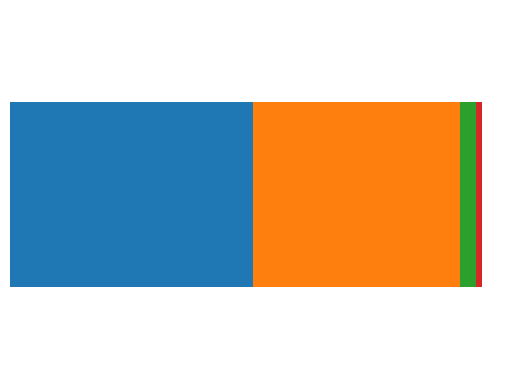

In [15]:


ax = result[['percentage']].T.plot.barh(stacked=True, legend=False)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')

# Remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.show()


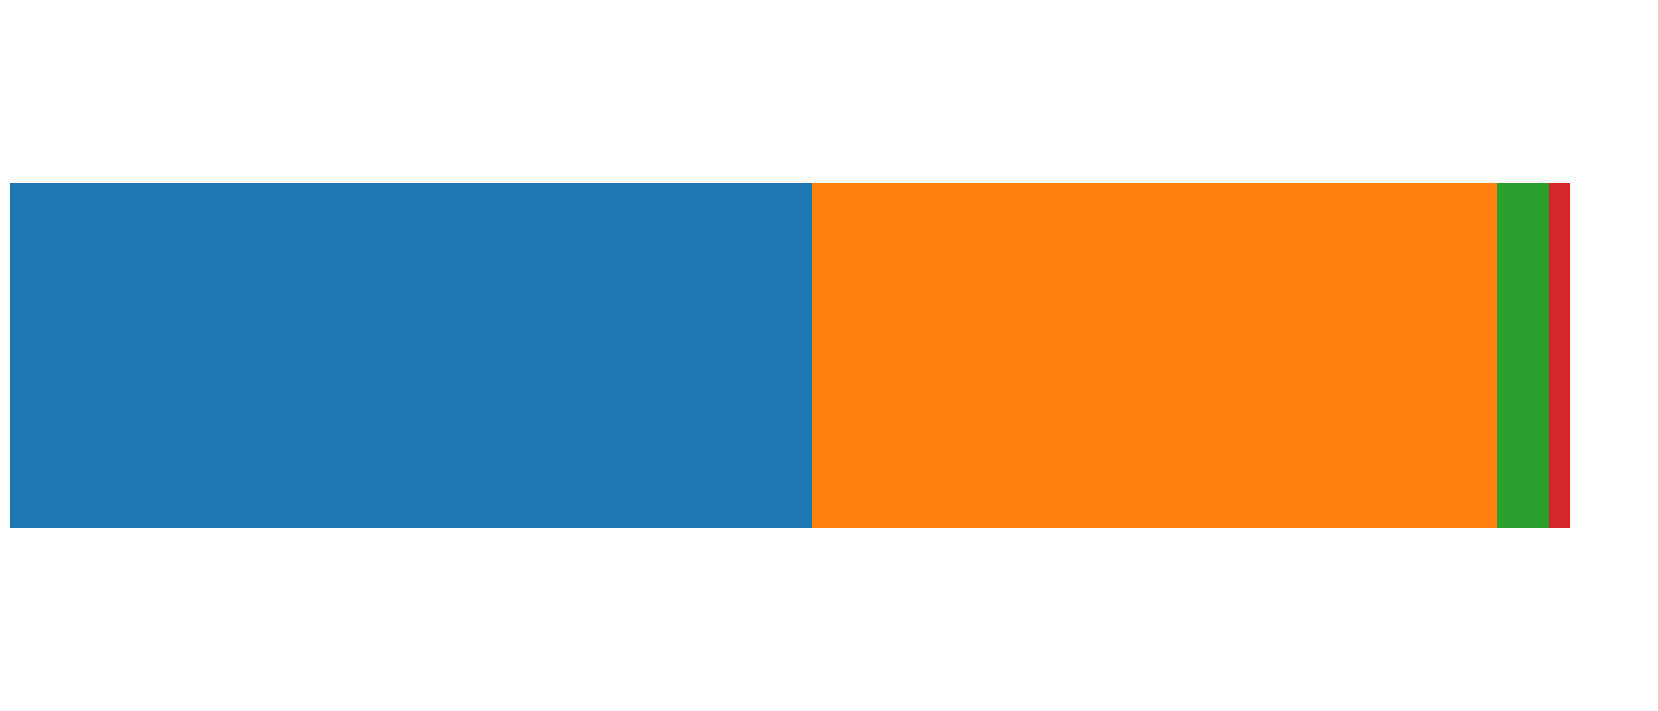

In [28]:
ax = result[['percentage']].T.plot.barh(stacked=True, legend=False)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')

# Remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Adjust the figure size and remove space around the plot
fig = ax.get_figure()
fig.subplots_adjust(left=-0.3, right=1.3, top=1, bottom=-0.2)
fig.set_size_inches(ax.get_window_extent().width / fig.dpi, ax.get_window_extent().height / fig.dpi)

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()



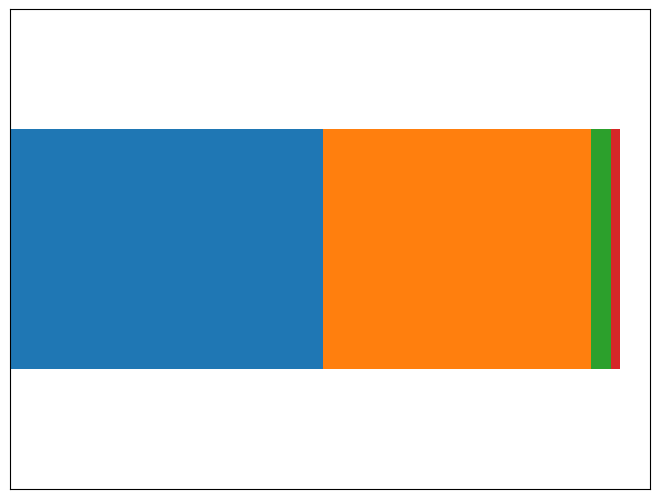

In [24]:
import matplotlib.pyplot as plt

# Create the plot
ax = result[['percentage']].T.plot.barh(stacked=True, legend=False)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')



# Use tight_layout to remove extra space
plt.tight_layout(pad=0)

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


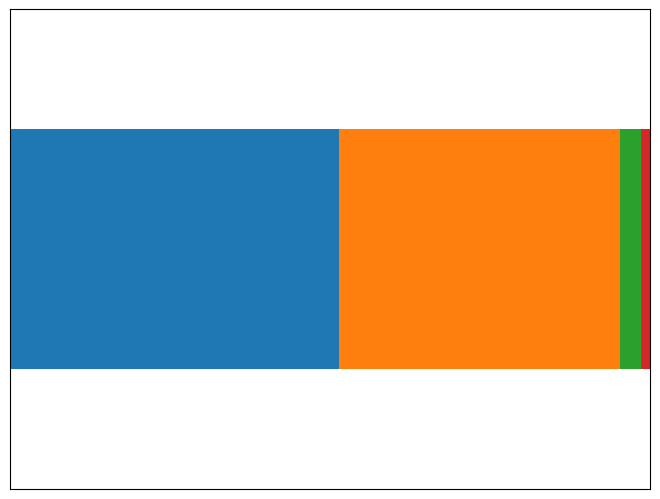

In [26]:

# Create the plot
ax = result[['percentage']].T.plot.barh(stacked=True, legend=False)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')



# Adjust the limits to remove whitespace inside the spines
ax.margins(0)

# Use tight_layout to remove extra space
plt.tight_layout(pad=0)

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


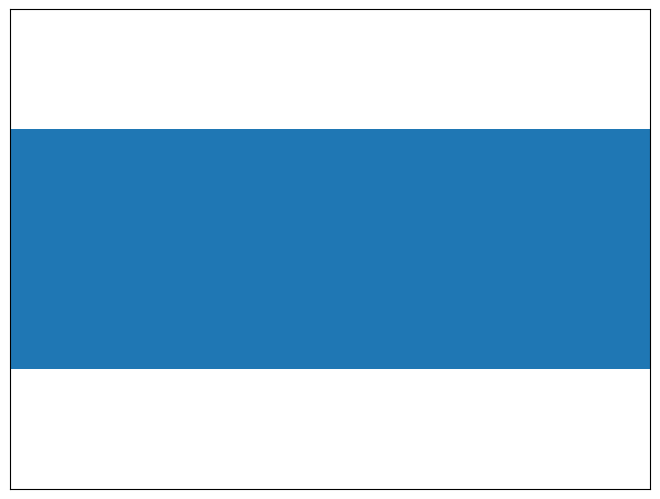

In [27]:
import matplotlib.pyplot as plt

# Create the plot
ax = result[['percentage']].T.plot.barh(stacked=True, legend=False)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')

# Remove the box around the plot
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Adjust the limits to remove whitespace inside the spines
ax.set_xlim(result['percentage'].min(), result['percentage'].max())
ax.set_ylim(-0.5, 0.5)  # Adjust based on your data

# Use tight_layout to remove extra space
plt.tight_layout(pad=0)

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


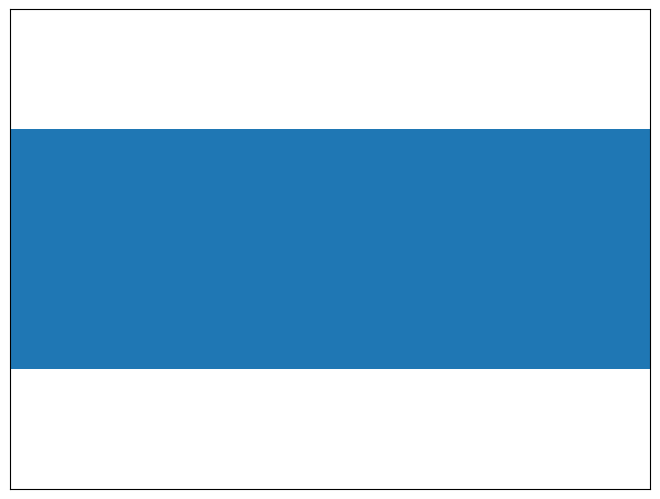

In [30]:


# Create the plot
ax = result[['percentage']].T.plot.barh(stacked=True, legend=False)
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')


# Adjust the limits to remove whitespace inside the spines
ax.set_xlim(result['percentage'].min(), result['percentage'].max())
ax.set_ylim(-0.5, 0.5)  # Adjust based on your data

# Remove space around the plot
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


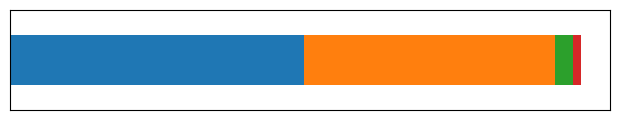

In [32]:
import matplotlib.pyplot as plt

# Create the plot
fig, ax = plt.subplots(figsize=(6, 1))  # Adjust the height as needed
result[['percentage']].T.plot.barh(stacked=True, legend=False, ax=ax)

# Remove the labels and ticks
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')



# Remove space around the plot
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


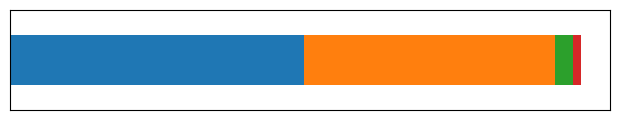

In [34]:
import matplotlib.pyplot as plt

# Create the plot with custom axes
fig = plt.figure(figsize=(6, 1))  # Adjust the width and height as needed
ax = fig.add_axes([0, 0, 1, 1])  # [left, bottom, width, height]

result[['percentage']].T.plot.barh(stacked=True, legend=False, ax=ax)

# Remove the labels and ticks
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')

# Remove the box around the plot

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


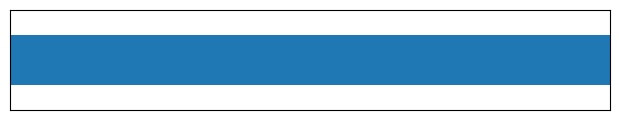

In [36]:
import matplotlib.pyplot as plt

# Create the plot with custom axes
fig = plt.figure(figsize=(6, 1))  # Adjust the width and height as needed
ax = fig.add_axes([0, 0, 1, 1])  # [left, bottom, width, height]

result[['percentage']].T.plot.barh(stacked=True, legend=False, ax=ax)

# Remove the labels and ticks
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')


# Adjust the limits to remove whitespace inside the spines
ax.set_xlim(result['percentage'].min(), result['percentage'].max())
ax.set_ylim(-0.5, 0.5)  # Adjust based on your data

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


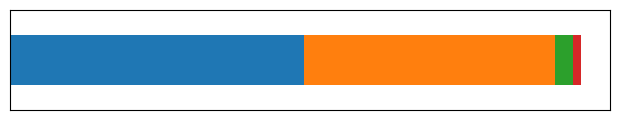

In [38]:
import matplotlib.pyplot as plt

# Create the plot
fig, ax = plt.subplots(figsize=(6, 1))  # Adjust the width and height as needed
result[['percentage']].T.plot.barh(stacked=True, legend=False, ax=ax)

# Remove the labels and ticks
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')


# Set the position of the plot to fill the entire figure
ax.set_position([0, 0, 1, 1])  # [left, bottom, width, height]

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()


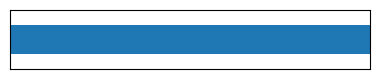

In [40]:
import matplotlib.pyplot as plt

# Create the plot
fig, ax = plt.subplots(figsize=(6, 1))  # Adjust the width and height as needed
result[['percentage']].T.plot.barh(stacked=True, legend=False, ax=ax)

# Remove the labels and ticks
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.yaxis.set_ticks_position('none') 
ax.xaxis.set_ticks_position('none')


# Set the axis limits to remove whitespace inside the spines
ax.set_xlim(result['percentage'].min(), result['percentage'].max())
ax.set_ylim(-0.5, 0.5)  # Adjust based on your data

# Adjust the figure size to fit the data tightly
fig.set_size_inches(ax.get_window_extent().width / fig.dpi, ax.get_window_extent().height / fig.dpi)

# Save the figure with tight bounding box
plt.savefig('plot.png', bbox_inches='tight', pad_inches=0)

plt.show()
